In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yogeshm01/spotify-artist-streaming-analytics-20152025")

print("Path to dataset files:", path)

100%|██████████| 6.83M/6.83M [00:00<00:00, 119MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yogeshm01/spotify-artist-streaming-analytics-20152025/versions/1


In [ ]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("/content/spotify_data_processed.csv")
df.head(5)


,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,...,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15,0.74,...,Medium,Quiet,A,Minor,False,2,False,9.472782,0.445,1
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44,0.46,...,Medium,Moderate,C,Minor,True,2,False,6.908755,0.450,3
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62,0.80,...,Medium,Quiet,G#,Major,True,1,False,6.908755,0.710,2
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78,0.98,...,Medium,Quiet,C#,Major,False,4,False,6.908755,0.880,4
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74,0.18,...,Medium,Moderate,A#,Minor,False,3,False,7.601402,0.460,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             85000 non-null  object 
 1   track_name           85000 non-null  object 
 2   artist_name          85000 non-null  object 
 3   album_name           85000 non-null  object 
 4   release_date         85000 non-null  object 
 5   genre                85000 non-null  object 
 6   duration_ms          85000 non-null  int64  
 7   popularity           85000 non-null  int64  
 8   danceability         85000 non-null  float64
 9   energy               85000 non-null  float64
 10  key                  85000 non-null  int64  
 11  loudness             85000 non-null  float64
 12  mode                 85000 non-null  int64  
 13  instrumentalness     85000 non-null  float64
 14  tempo                85000 non-null  float64
 15  stream_count         85000 non-null 

In [ ]:
df.sample(10,random_state=1)

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,...,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
76562,TRK-140BA9CBA575,Commercial rest easy,Mark Webb,Wait month,2016-07-13,Classical,225280,36,0.52,0.59,...,Medium,Moderate,D,Major,False,3,False,6.908755,0.555,4
42148,TRK-63111B9548D7,Knowledge including,Andrew Jacobs,Painting pattern,2017-08-03,R&B,291921,59,0.71,0.48,...,Medium,Moderate,A,Major,False,3,False,6.908755,0.595,3
57564,TRK-21EE66BCF7A2,Commercial,Jennifer Sanchez,Set board,2018-11-16,Metal,305878,58,0.85,0.86,...,Medium,Moderate,C#,Major,False,4,False,8.699681,0.855,5
74611,TRK-14E2FC3A4133,Medical health myself,William Moreno,Thank,2015-04-30,Hip-Hop,267527,50,0.70,0.85,...,Medium,Quiet,F#,Minor,False,2,False,6.908755,0.775,1
58571,TRK-7A5681820A01,Ground hard agreement,Robert Sharp,Able head,2019-02-10,Indie,292071,64,0.42,0.56,...,Medium,Quiet,D#,Major,True,1,True,8.294300,0.490,2
82938,TRK-AC1F1AEC4E3A,Blood participant,Lawrence Evans,Because sister,2022-02-17,Classical,136207,42,0.32,0.36,...,Medium,Moderate,D,Major,False,1,False,7.601402,0.340,1
73827,TRK-84EA334EA8B0,Indeed,Danielle Murray,Actually wear,2023-08-18,EDM,274968,54,0.86,0.36,...,Medium,Loud,G,Minor,False,3,False,6.908755,0.610,1
11640,TRK-8F69C48186A8,Across democratic,Christine Ward MD,Training,2015-10-15,Jazz,398403,54,0.44,0.65,...,Medium,Moderate,A,Minor,True,4,False,11.211834,0.545,1
49504,TRK-3B34002EA88D,See key,Matthew Robinson,Return,2023-01-03,Hip-Hop,395217,56,0.86,0.69,...,Medium,Quiet,D,Minor,False,1,False,6.908755,0.775,7
28074,TRK-F22DD4C55374,Commercial recent a condition,Mark Long,Successful probably,2017-04-23,Country,325931,55,0.48,0.27,...,Medium,Moderate,G#,Minor,True,2,True,8.006701,0.375,3


In [ ]:
df_sorted = df.sort_values('log_stream_count' ,ascending=False)
df_sorted.head()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,...,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
14212,TRK-AA1CBF75B8FC,Simple free moment,Russell Potter,Window,2024-05-10,Metal,106539,100,0.69,0.27,...,High,Loud,C,Minor,False,2,False,16.811243,0.48,1
14201,TRK-41948F195FF2,Who treat technology around response,Johnny Steele,Along,2025-12-11,EDM,135210,100,0.79,0.91,...,High,Loud,E,Minor,False,4,False,16.811243,0.85,1
46274,TRK-C9F922E0B135,American peace three,Isaac Young,War law,2017-06-16,Pop,223636,90,0.86,0.12,...,High,Quiet,C,Minor,False,2,False,16.811243,0.49,1
46171,TRK-D4169CF6FD4A,Anyone deep,Scott Gray,Reveal real,2018-12-12,R&B,389619,100,0.28,0.96,...,High,Quiet,D#,Major,False,4,False,16.811243,0.62,2
2749,TRK-32C830217A7A,Front sure capital how,Marissa Green,Yeah,2019-04-09,Jazz,311192,100,0.29,0.05,...,High,Moderate,A#,Major,False,2,False,16.811243,0.17,1


In [ ]:
df.shape

(85000, 33)

In [ ]:
ozet= pd.DataFrame({
    "dtype":df.dtypes,
    "eksik_deger":df.isnull().sum(),
    "unique_deger":df.nunique(),
    "eksik_deger_yuzdesi":(df.isnull().mean()*100).round(2),
})

print(ozet)

                       dtype  eksik_deger  unique_deger  eksik_deger_yuzdesi
track_id              object            0         85000                  0.0
track_name            object            0         68952                  0.0
artist_name           object            0         62391                  0.0
album_name            object            0         43171                  0.0
release_date          object            0          4018                  0.0
genre                 object            0            12                  0.0
duration_ms            int64            0         75084                  0.0
popularity             int64            0            99                  0.0
danceability         float64            0            95                  0.0
energy               float64            0            98                  0.0
key                    int64            0            12                  0.0
loudness             float64            0          5401                  0.0

In [ ]:
df.isnull().sum()

,0
track_id,0
track_name,0
artist_name,0
album_name,0
release_date,0
genre,0
duration_ms,0
popularity,0
danceability,0
energy,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,explicit,release_year,release_month,duration_minutes,release_quarter,log_stream_count,upbeat_score,artist_track_count
count,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,8.500000e+04,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000
mean,254913.824294,48.162894,0.520710,0.505412,5.515988,-27.999300,0.500141,0.399781,129.948351,2.143547e+05,0.201329,2019.988012,6.512518,4.248564,2.505106,8.404062,0.513061,2.302612
std,95300.233207,14.829752,0.270799,0.279774,3.454069,15.598365,0.500003,0.231470,40.444321,1.680637e+06,0.400996,3.169136,3.452717,1.588337,1.117692,1.906501,0.194280,3.079938
min,90004.000000,0.000000,0.050000,0.020000,0.000000,-55.000000,0.000000,0.000000,60.000000,1.000000e+03,0.000000,2015.000000,1.000000,1.500067,1.000000,6.908755,0.035000,1.000000
25%,171871.500000,38.000000,0.290000,0.260000,2.750000,-41.470000,0.000000,0.198000,94.840000,1.000000e+03,0.000000,2017.000000,4.000000,2.864525,2.000000,6.908755,0.375000,1.000000
50%,254920.500000,47.000000,0.520000,0.500000,6.000000,-27.970000,1.000000,0.399000,129.990000,2.000000e+03,0.000000,2020.000000,7.000000,4.248675,3.000000,7.601402,0.510000,1.000000
75%,337203.250000,57.000000,0.760000,0.750000,9.000000,-14.500000,1.000000,0.600000,165.030000,9.000000e+03,0.000000,2023.000000,10.000000,5.620054,4.000000,9.105091,0.650000,2.000000
max,420000.000000,100.000000,0.990000,0.990000,11.000000,-1.000000,1.000000,0.800000,200.000000,2.000000e+07,1.000000,2025.000000,12.000000,7.000000,4.000000,16.811243,0.990000,44.000000


In [ ]:
sayisal_sutunlar = df.select_dtypes(include=[np.number]).columns.tolist()
sozel_sutunlar = df.select_dtypes(exclude=[np.number]).columns.tolist()
sayisal_sutunlar
#id değerlerinin benzersiz olması bir işimize yaramaz kaldıralım kolonu
#sayisal_sutunlar.remove("track_id")

['duration_ms',
 'popularity',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'instrumentalness',
 'tempo',
 'stream_count',
 'explicit',
 'release_year',
 'release_month',
 'duration_minutes',
 'release_quarter',
 'log_stream_count',
 'upbeat_score',
 'artist_track_count']

skew: 0.00 kurt: -1.20
skew: 0.67 kurt: 0.76
skew: -0.00 kurt: -1.19
skew: 0.00 kurt: -1.20
skew: -0.01 kurt: -1.22
skew: -0.00 kurt: -1.20
skew: -0.00 kurt: -2.00
skew: -0.00 kurt: -1.20
skew: 0.00 kurt: -1.20
skew: 10.52 kurt: 115.25
skew: 1.49 kurt: 0.22
skew: 0.00 kurt: -1.22
skew: -0.01 kurt: -1.21
skew: 0.00 kurt: -1.20
skew: -0.01 kurt: -1.36
skew: 1.78 kurt: 3.49
skew: 0.00 kurt: -0.60
skew: 5.64 kurt: 48.23


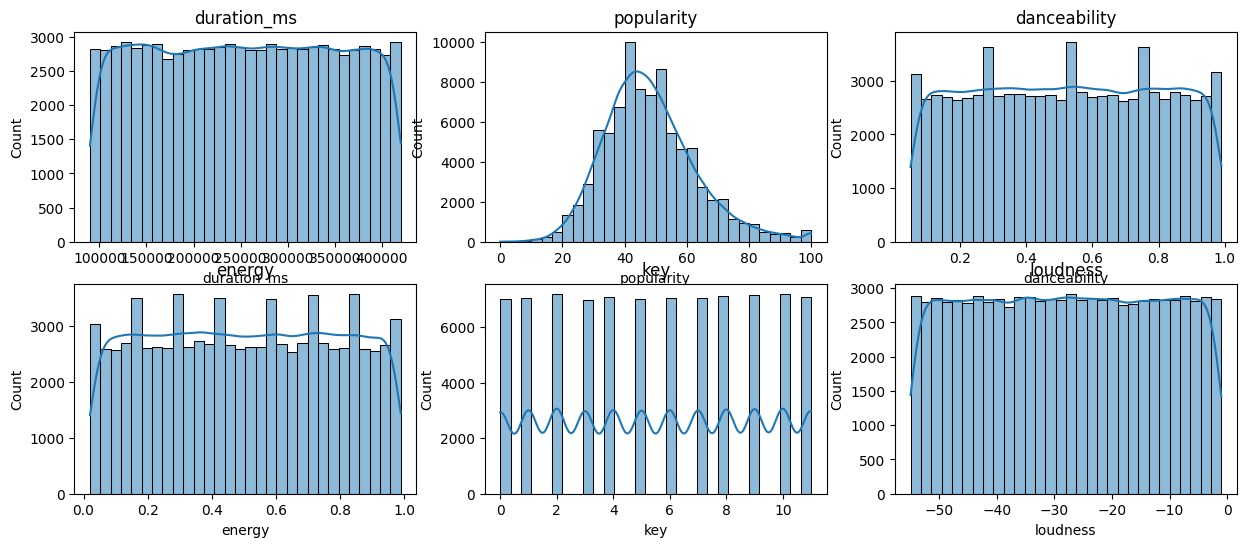

In [ ]:
for col in sayisal_sutunlar:
  print(f"skew: {df[col].skew():.2f} kurt: {df[col].kurt():.2f}")

fig,axes = plt.subplots(2,3,figsize=(15,6))
for ax ,col in zip(axes.flatten(),sayisal_sutunlar):
  sns.histplot(df[col], ax=ax, kde=True,bins =30)
  ax.set_title(col)
plt.tight_layout
plt.savefig("histogramlar.png",dpi = 300)
plt.show ()

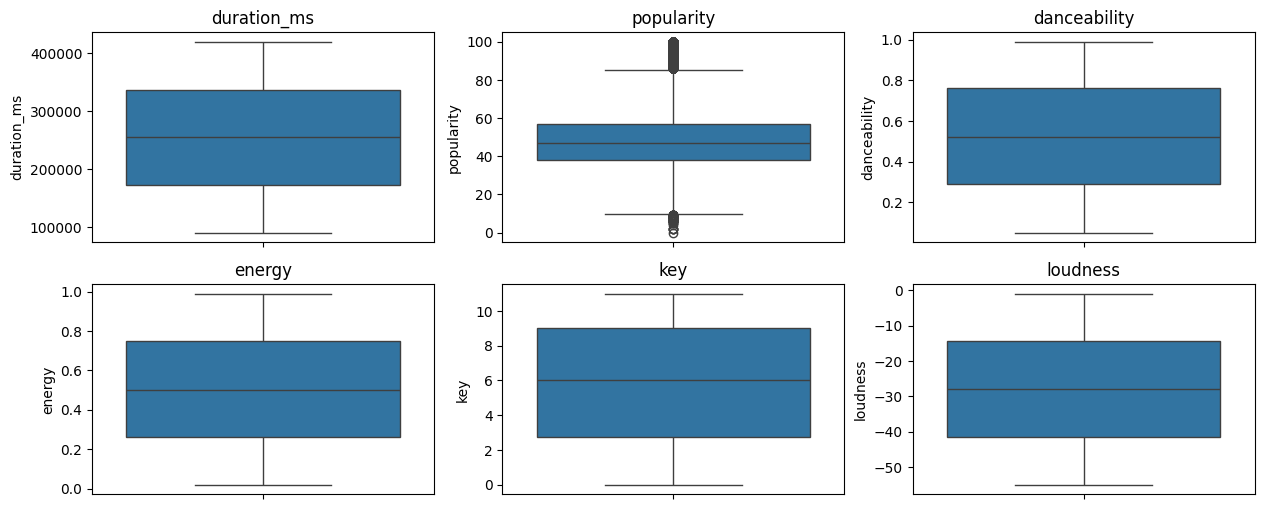

In [ ]:
fig,axes = plt.subplots(2,3,figsize=(15,6))
for ax ,col in zip(axes.flatten(),sayisal_sutunlar):
  sns.boxplot(y=df[col], ax=ax)
  ax.set_title(col)
plt.tight_layout
plt.savefig("boxplot.png",dpi = 300)
plt.show ()

track_id
TRK-1AFF404AA899    0.0
TRK-BEBD53DA84E1    0.0
TRK-6A32496762D7    0.0
TRK-47AA7523463E    0.0
TRK-25ADA22E3B06    0.0
                   ... 
TRK-EAED8F014178    0.0
TRK-04AD6A91EF55    0.0
TRK-C7897F3EFC11    0.0
TRK-3EB4332CA819    0.0
TRK-5BB824DBF141    0.0
Name: proportion, Length: 85000, dtype: float64
track_name
Stand                               0.04
Ten                                 0.04
Expert                              0.03
Fine                                0.03
Shoulder                            0.03
                                    ... 
Son election weight                 0.00
Particular boy determine            0.00
Religious card performance early    0.00
Traditional though party force      0.00
After kitchen enter                 0.00
Name: proportion, Length: 68952, dtype: float64
artist_name
Michael Smith          0.05
Michael Johnson        0.05
David Smith            0.04
Christopher Johnson    0.03
David Johnson          0.03
                 

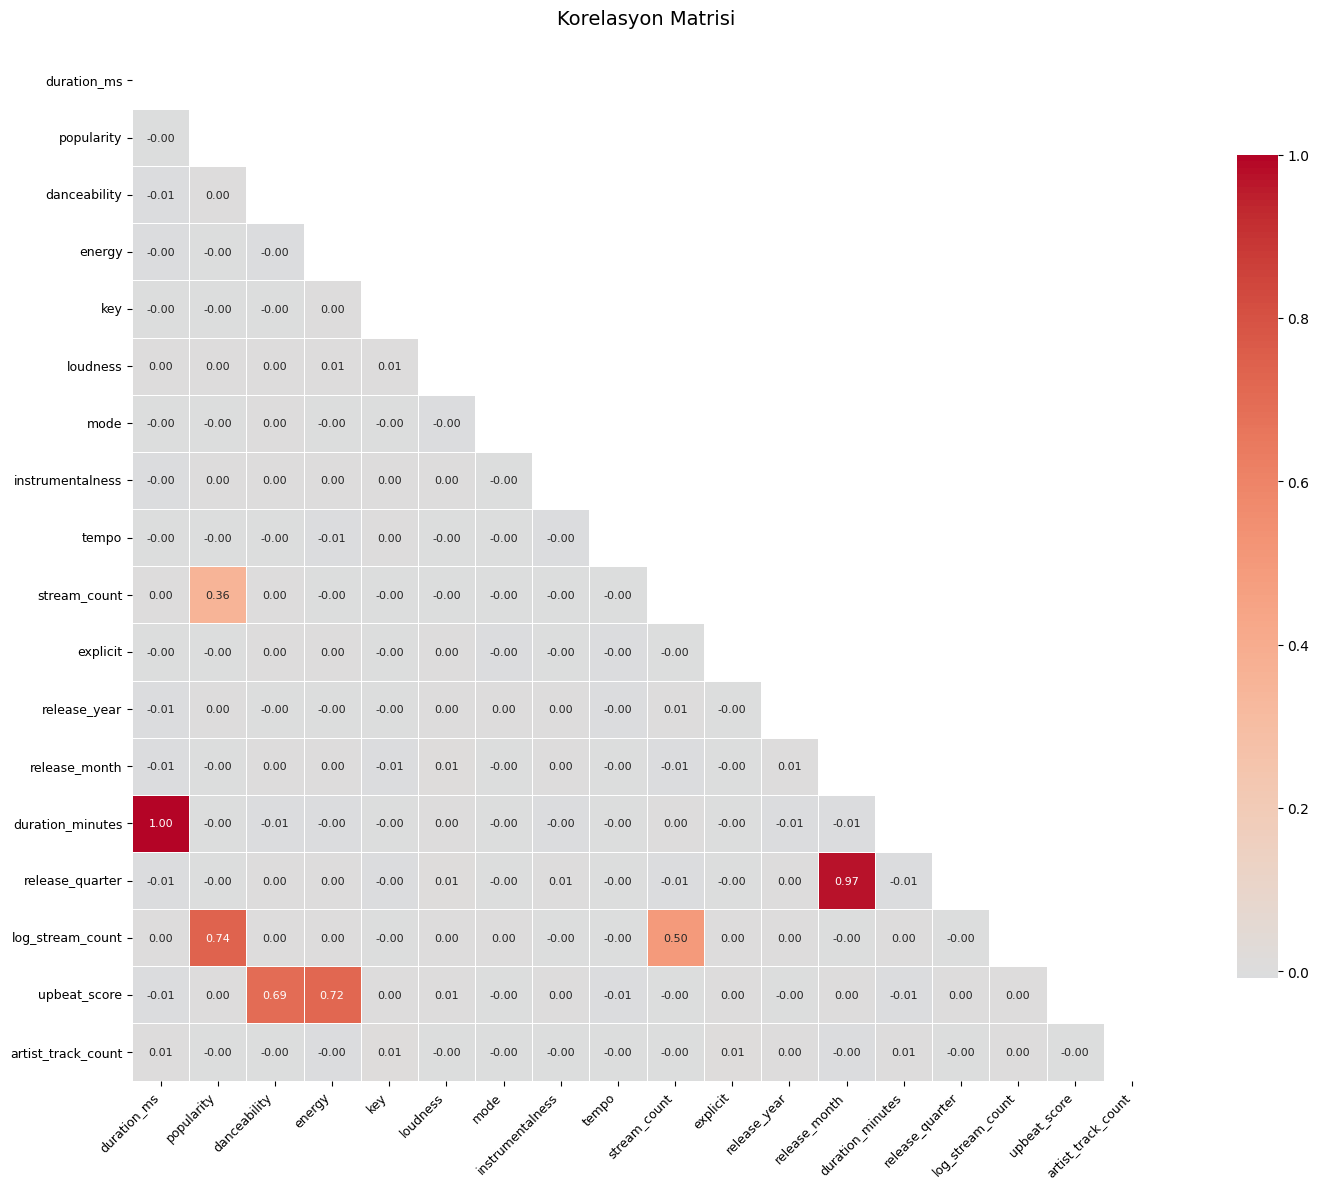

In [ ]:
for col in sozel_sutunlar:

  print((df[col].value_counts(dropna=False, normalize=True)*100).round(2))

korelasyon = df[sayisal_sutunlar].corr(numeric_only=True)
print("------ Korelasyon Matrisi-----")
print(korelasyon.round(2))

plt.figure(figsize=(16, 12))

mask = np.triu(np.ones_like(korelasyon, dtype=bool))

sns.heatmap(
    korelasyon,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

plt.title("Korelasyon Matrisi", fontsize=14, pad=20)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("korelasyon_matrisi.png", dpi=200, bbox_inches="tight")
plt.show()

korelasyon verileri bize anlamlı bir bilgi vermedi. aralarında korelasyon olan veriler hali hazırda birbiri ile direkt olarak ilişkili. Dakika ve milisaniye gibi veriler zaten birbiri içinde korelasyon içerisindeler. Bu kolonların bazılarını kaldırmak ya da verilerde anlamlı bir çıkarım içerisinde olmadıklarını anlamamız gerekiyor.

In [ ]:
# Bu adımdan itibaren istatistiksel olarak verimizi yorumlayacağız.

In [ ]:
def ortalama_guven_aralığı(seri,guven=0.95):
  veri = seri.dropna()
  n = len(veri)
  ortalama = veri.mean()
  sem = stats.sem(veri) # standart error of the mean
  t_kritik = stats.t.ppf((1+guven)/2 ,df =n-1)
  hata_payi = t_kritik*sem
  return ortalama,ortalama-hata_payi,ortalama+hata_payi

print(f"{'değişken':20s},{'Ortalama':>12s},{'%95 Alt':>12s},{'%95 Üst':>12s}")
for degisken in sayisal_sutunlar:
  ortalama,alt,ust = ortalama_guven_aralığı(df[degisken])
  print(f"{degisken:20s},{ortalama:>12.2f},{alt:>12.2f},{ust:>12.2f}")

değişken            ,    Ortalama,     %95 Alt,     %95 Üst
duration_ms         ,   254913.82,   254273.15,   255554.50
popularity          ,       48.16,       48.06,       48.26
danceability        ,        0.52,        0.52,        0.52
energy              ,        0.51,        0.50,        0.51
key                 ,        5.52,        5.49,        5.54
loudness            ,      -28.00,      -28.10,      -27.89
mode                ,        0.50,        0.50,        0.50
instrumentalness    ,        0.40,        0.40,        0.40
tempo               ,      129.95,      129.68,      130.22
stream_count        ,   214354.68,   203056.23,   225653.13
explicit            ,        0.20,        0.20,        0.20
release_year        ,     2019.99,     2019.97,     2020.01
release_month       ,        6.51,        6.49,        6.54
duration_minutes    ,        4.25,        4.24,        4.26
release_quarter     ,        2.51,        2.50,        2.51
log_stream_count    ,        8.40,      

In [ ]:
print(f"{'Değişken':20s} {'Shapiro-Wilk p':>16s} {'DAgostino p'} Yorum ")
for col in sayisal_sutunlar:
  veri= df[col].dropna()
  # shapiro n> 5000 den fazla olursa güvenilmez olur
  ornek = veri.sample(min(len(veri),5000),random_state=0)
  sw_stat, sw_p = stats.shapiro(ornek)
  da_stat, da_p = stats.normaltest(veri)
  yorum = "Normal dağılım varsayımı sağlanmaktadır." if sw_p > 0.05 else "Normal dağılım varsayımı sağlanmamaktadır."
  print(f"{col:20s} {sw_p:>16.4f} {da_p:>16.4f} {yorum}")

Değişken               Shapiro-Wilk p DAgostino p Yorum 
duration_ms                    0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
popularity                     0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
danceability                   0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
energy                         0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
key                            0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
loudness                       0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
mode                           0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
instrumentalness               0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
tempo                          0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
stream_count                   0.0000           0.0000 Normal

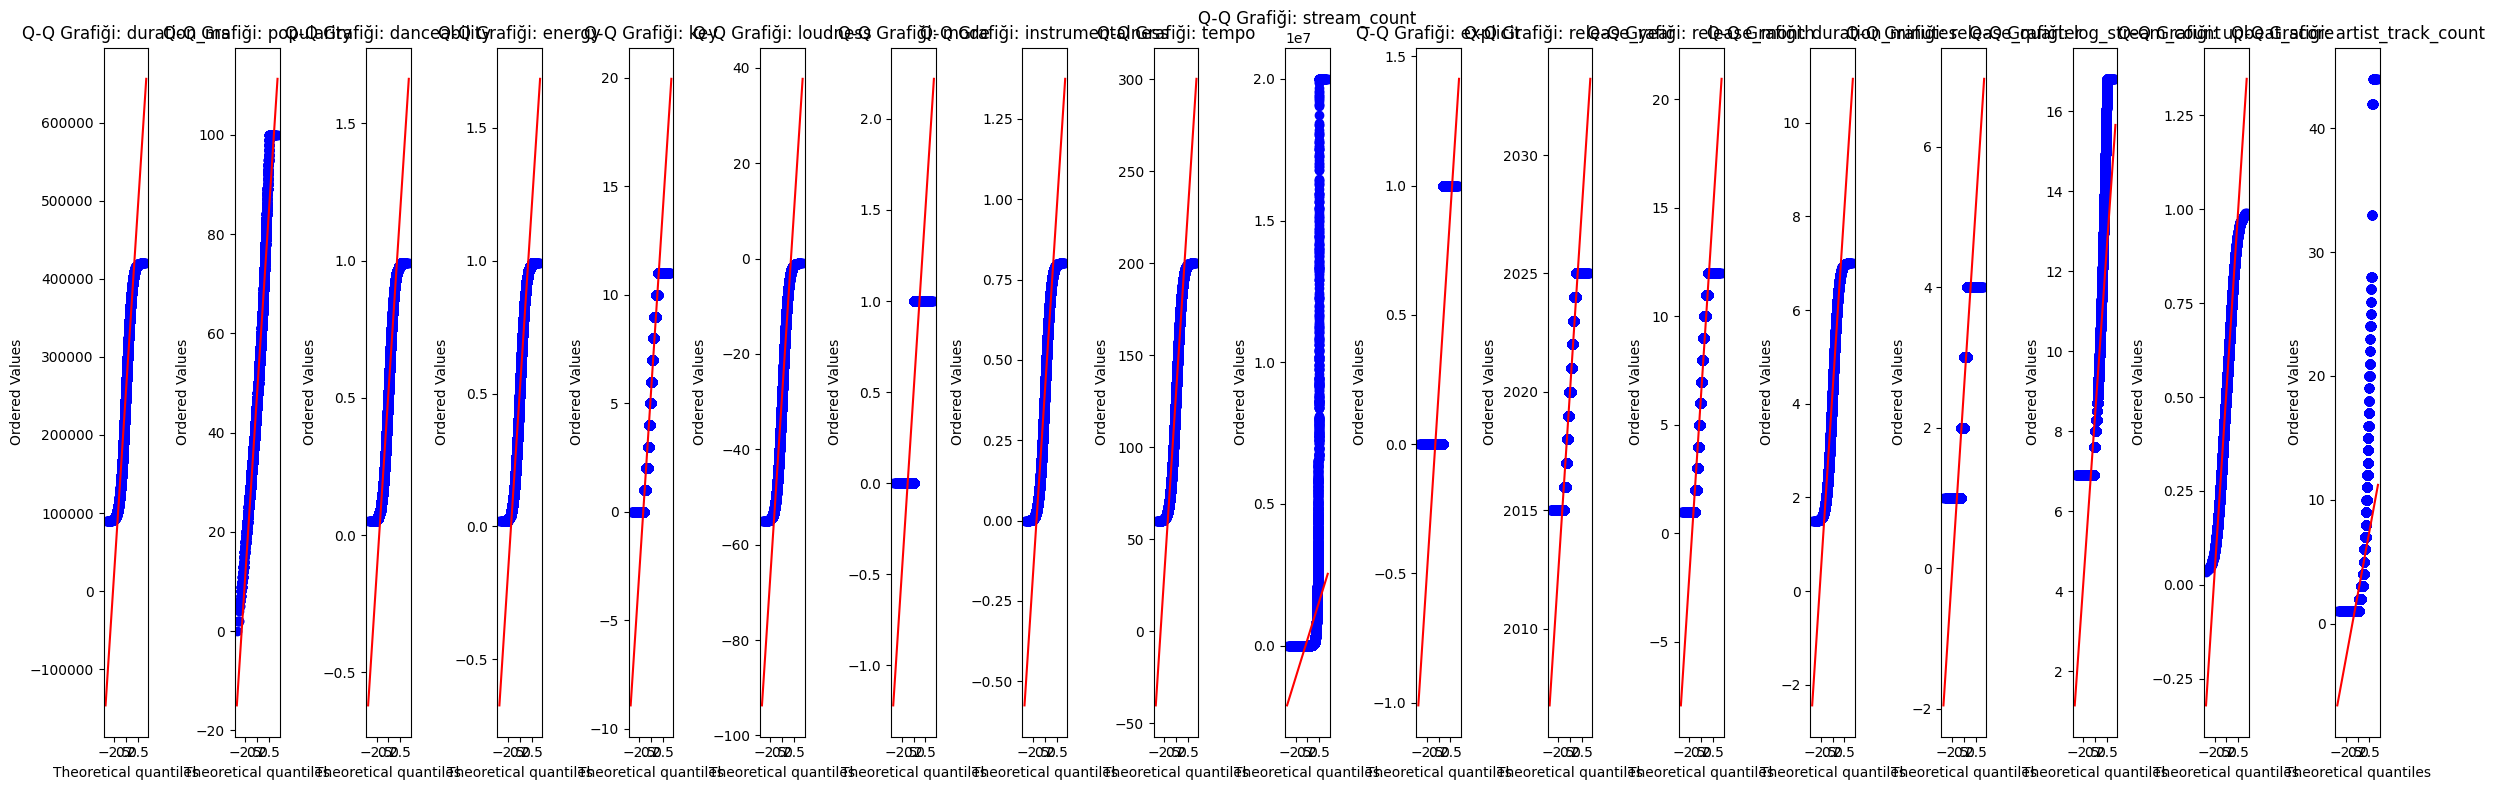

In [ ]:
fig, axes = plt.subplots(1, len(sayisal_sutunlar), figsize=(24, 8))
for ax, col in zip(axes, sayisal_sutunlar):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Grafiği: {col}")
plt.tight_layout()
plt.show()

In [ ]:
grup0 = df.loc[df["explicit"] == 0, "stream_count"].dropna()
grup1 = df.loc[df["explicit"] == 1, "stream_count"].dropna()

levene_stat, levene_p = stats.levene(grup0, grup1)
print("Varsayımlar homojendir." if levene_p > 0.05 else "Varsayımlar homojen değildir.")
__, p0=stats.shapiro(grup0.sample(min(len(grup0),5000),random_state=0))
__, p1=stats.shapiro(grup1.sample(min(len(grup1),5000),random_state=0))
normal_mi = (p0>0.05) and (p1>0.05)
print(f"grup normallik p değerleri: churn=0 -> {p0:.4f},churn=1 -> {p1:.4f}")

Varsayımlar homojendir.
grup normallik p değerleri: churn=0 -> 0.0000,churn=1 -> 0.0000


In [ ]:
gruplar= [g["danceability"].dropna().values for _,g in df.groupby("country")]

f_stat, anova_p = stats.f_oneway(*gruplar)
h_stat, kw_p= stats.kruskal(*gruplar)

print(f" tek yönlü anova: f={f_stat:.3f},p={anova_p:.4f}")
print(f"kruskal-wallis: h={h_stat:.3f},p={kw_p:.4f}")

 tek yönlü anova: f=0.675,p=0.7323
kruskal-wallis: h=6.055,p=0.7344


In [ ]:

genel_ortalama = df["danceability"].mean()
ss_between = sum(len(g)*(g.mean()-genel_ortalama)**2 for g in gruplar)
ss_total = sum((df["danceability"].dropna()-genel_ortalama)**2)
eta_kare = ss_between/ss_total
print(f"Eta Kare: {eta_kare:.4f} (0.01 küçük,0.06 orta, 0.14 büyük etki)")

Eta Kare: 0.0001 (0.01 küçük,0.06 orta, 0.14 büyük etki)


In [ ]:
tukey = pairwise_tukeyhsd(
    endog=df["danceability"].dropna(),
    groups=df.loc[df["danceability"].notna(), "country"],
    alpha=0.05
)

print(tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------
     Australia         Brazil  -0.0047 0.9831 -0.0178 0.0085  False
     Australia         Canada  -0.0019    1.0 -0.0151 0.0112  False
     Australia         France  -0.0019    1.0  -0.015 0.0113  False
     Australia        Germany  -0.0019    1.0 -0.0151 0.0113  False
     Australia          India  -0.0014    1.0 -0.0145 0.0118  False
     Australia          Japan  -0.0031 0.9991 -0.0163   0.01  False
     Australia         Mexico   0.0032 0.9989   -0.01 0.0165  False
     Australia United Kingdom   0.0007    1.0 -0.0125 0.0138  False
     Australia  United States   0.0023 0.9999 -0.0109 0.0155  False
        Brazil         Canada   0.0027 0.9997 -0.0104 0.0158  False
        Brazil         France   0.0028 0.9997 -0.0104 0.0159  False
        Brazil        Germany   0.0028 0.9997 -0

In [ ]:
def cramers_v(x,y):
  tablo =pd.crosstab(x,y)
  chi2 = stats.chi2_contingency(tablo)[0]
  n =tablo.sum().sum()
  k= min(tablo.shape)-1
  return np.sqrt(chi2/(n*k))

capraz = pd.crosstab(df["stream_count"],df["popularity_category"])
chi2,p,dof,beklenen =stats.chi2_contingency(capraz)
v= cramers_v(df["stream_count"],df["popularity_category"])
print(f"chi2={chi2:.4f},p={p:.4f},v={v:.4f}")
print(f"Cramer's V: {v:.4f}")
print("\n Çapraz Tablo")
print(capraz)

chi2=47874.3342,p=0.0000,v=0.5307
Cramer's V: 0.5307

 Çapraz Tablo
popularity_category  High   Low  Medium
stream_count                           
1000                  164  7938   24552
2000                  163  1547    9784
3000                  141   591    5443
4000                  134   258    3592
5000                  164   157    2592
...                   ...   ...     ...
19674000                1     0       0
19853000                1     0       0
19889000                1     0       0
19952000                1     0       0
20000000              458     0       0

[2250 rows x 3 columns]


In [ ]:
 def  korelasyon_p_matrisi(veri,yontem ="pearson"):
  sutunlar = veri.columns
  kat = pd.DataFrame(np.ones((len(sutunlar),len(sutunlar))),index=sutunlar,columns=sutunlar)
  pval = pd.DataFrame(np.zeros((len(sutunlar),len(sutunlar))),index=sutunlar,columns=sutunlar)
  for i in sutunlar:
    for j in sutunlar:
      if i == j:
        kat.loc[i,j] = 1.0
        pval.loc[i,j] = 0.0
        continue
      ortak = veri[[i,j]].dropna()
      x_seri,y_seri = ortak.iloc[:,0],ortak.iloc[:,1]
      if yontem == "pearson":
        r,p = stats.pearsonr(x_seri,y_seri)
      else:
        r,p = stats.spearmanr(x_seri,y_seri)
      kat.loc[i,j] = float(r)
      pval.loc[i,j] = float(p)
  return kat,pval

pearson_r, pearson_p = korelasyon_p_matrisi(df[sayisal_sutunlar],"pearson")
print("--- pearson korelasyon katsayıları ---")
print(pearson_r)
print("\n--- pearson p değerleri ---")
print(pearson_p.round(4))

--- pearson korelasyon katsayıları ---
                    duration_ms  popularity  danceability    energy       key  \
duration_ms            1.000000   -0.000556     -0.005154 -0.004043 -0.003547   
popularity            -0.000556    1.000000      0.003193 -0.000378 -0.003287   
danceability          -0.005154    0.003193      1.000000 -0.004136 -0.002843   
energy                -0.004043   -0.000378     -0.004136  1.000000  0.004570   
key                   -0.003547   -0.003287     -0.002843  0.004570  1.000000   
loudness               0.002002    0.003281      0.002430  0.005471  0.005597   
mode                  -0.001776   -0.001537      0.000173 -0.003853 -0.003193   
instrumentalness      -0.004072    0.002292      0.004439  0.002280  0.000474   
tempo                 -0.001482   -0.002763     -0.002584 -0.006582  0.002370   
stream_count           0.000507    0.357505      0.000448 -0.001404 -0.001013   
explicit              -0.003857   -0.000903      0.001612  0.001607 -0

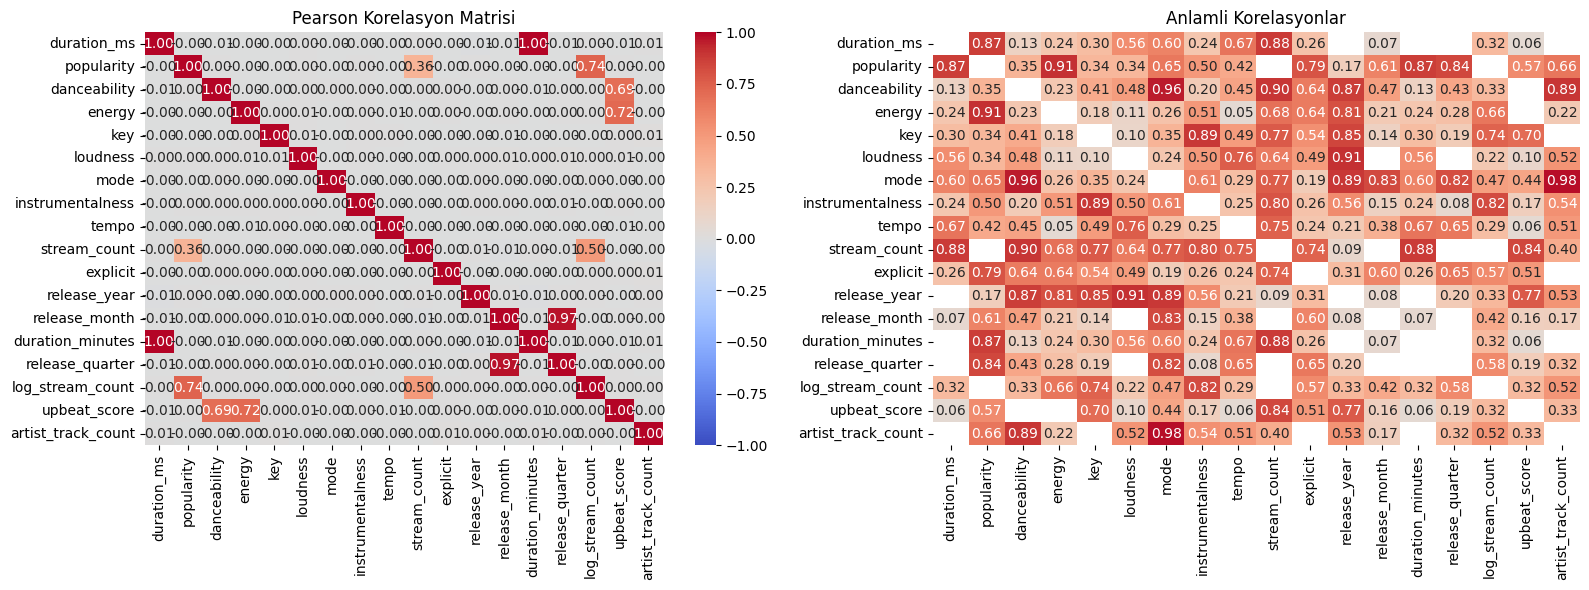

In [ ]:
fig , axes = plt.subplots(1,2, figsize=(16,6))
sns.heatmap(pearson_r,annot=True,fmt=".2f",cmap="coolwarm",center=0,vmin=-1,vmax=1,ax=axes[0])
axes[0].set_title("Pearson Korelasyon Matrisi")

anlamli_maske = pearson_p > 0.05

sns.heatmap(pearson_p,annot=True,fmt=".2f",cmap="coolwarm",center=0,vmin=-1,vmax=1,mask=~anlamli_maske,ax=axes[1],cbar=False)
axes[1].set_title("Anlamli Korelasyonlar")
plt.tight_layout()
plt.show()

In [ ]:
X_vif = df[["energy", "danceability", "upbeat_score", "loudness", "tempo"]].dropna()
X_vif = sm.add_constant(X_vif)
vif_tablosu = pd.DataFrame({
    "Değişken":X_vif.columns,
    "VIF":[VIF(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_tablosu)   # 1 yerine 0 dan başlattık

       Değişken           VIF
0         const  1.000000e+00
1        energy  1.000800e+15
2  danceability  1.000800e+15
3  upbeat_score  1.000800e+15
4      loudness  1.000037e+00
5         tempo  1.000051e+00


In [ ]:
X_vif = df[["energy", "danceability", "upbeat_score", "loudness", "tempo"]].dropna()
X_vif_const = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": X_vif.columns,
    "VIF": [VIF(X_vif_const.values, i) for i in range(1, X_vif_const.shape[1])]
})
print(vif_tablosu) # 0 index sabit değer çokta önemli değil onu yoksalım

       Değişken           VIF
0        energy  1.000800e+15
1  danceability  1.000800e+15
2  upbeat_score  1.000800e+15
3      loudness  1.000037e+00
4         tempo  1.000051e+00


In [ ]:
X_vif = df[["energy", "danceability", "upbeat_score", "loudness", "tempo"]].dropna()
X_vif = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": [X_vif.columns[i]for i in range(1, X_vif.shape[1])],
    "VIF": [VIF(X_vif.values, i) for i in range(1, X_vif.shape[1])]
})
print(vif_tablosu)

       Değişken           VIF
0        energy  1.000800e+15
1  danceability  1.000800e+15
2  upbeat_score  1.000800e+15
3      loudness  1.000037e+00
4         tempo  1.000051e+00


In [ ]:
model_verisi = df[["log_stream_count", "popularity"]].dropna()

model = smf.ols(formula="log_stream_count ~ popularity", data=model_verisi)
sonuc = model.fit()
print(sonuc.summary())

                            OLS Regression Results                            
Dep. Variable:       log_stream_count   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                 1.021e+05
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:26:56   Log-Likelihood:            -1.4192e+05
No. Observations:               85000   AIC:                         2.838e+05
Df Residuals:                   84998   BIC:                         2.839e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.8298      0.015    255.716      0.0

In [ ]:
model_verisi = df[["popularity", "danceability", "energy", "loudness", "tempo"]].dropna()

model = smf.ols(formula="popularity ~ danceability + energy + loudness + tempo", data=model_verisi)
sonuc = model.fit()
print(sonuc.summary())

                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6086
Date:                Sun, 20 Sep 2026   Prob (F-statistic):              0.656
Time:                        21:24:20   Log-Likelihood:            -3.4982e+05
No. Observations:               85000   AIC:                         6.997e+05
Df Residuals:                   84995   BIC:                         6.997e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       48.3014      0.237    203.910   

In [ ]:
pca_verisi = df[sayisal_sutunlar].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_verisi)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
acıklanan_varyans = pca.explained_variance_ratio_
print(acıklanan_varyans)

[1.15557408e-01 1.12071322e-01 1.10265856e-01 1.09191825e-01
 5.63804465e-02 5.61401045e-02 5.59760513e-02 5.57516533e-02
 5.57016411e-02 5.54138767e-02 5.53396171e-02 5.48894059e-02
 5.45844505e-02 3.77012488e-02 1.34542234e-02 1.58086884e-03
 9.84886883e-18 0.00000000e+00]
